# Telecom Customer Churn Analysis

## Executive Summary

This project analyzes customer churn in a telecommunications dataset to identify factors associated with customers leaving the service. The analysis included data inspection, data cleaning, exploratory data analysis, and visualization of important churn-related patterns.

The overall churn rate in the dataset is approximately 14.55%. The analysis found that customers with an International Plan had a substantially higher churn rate than customers without an International Plan. Customer Service Calls also showed a clear relationship with churn, with higher numbers of service calls generally associated with higher churn rates. In addition, churned customers had a higher average Total Day Charge than non-churned customers.

Several visualizations were created to understand customer churn distribution and the relationship between churn and important customer characteristics. These findings can help identify customer groups that may require additional attention.

Based on the analysis, telecommunications companies can monitor customers using International Plans, improve support for customers making frequent service calls, and investigate factors contributing to higher charges among customers who churn. These actions may help businesses better understand customer behavior and support future customer retention efforts.

# Data Loading & Inspection

In [2]:
import pandas as pd 
df = pd.read_csv("telecom-churn.csv")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

np.int64(0)

# Checking missing & duplicate values

In [2]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)


# Checking text columns

In [3]:
df.select_dtypes(include="object").columns

C:\Users\Hair\AppData\Local\Temp\ipykernel_4708\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['State', 'International plan', 'Voice mail plan'], dtype='str')

In [4]:
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].unique())
    print()

State
<ArrowStringArray>
['KS', 'OH', 'NJ', 'OK', 'AL', 'MA', 'MO', 'WV', 'RI', 'IA', 'MT', 'ID', 'VT',
 'VA', 'TX', 'FL', 'CO', 'AZ', 'NE', 'WY', 'IL', 'NH', 'LA', 'GA', 'AK', 'MD',
 'AR', 'WI', 'OR', 'DE', 'IN', 'UT', 'CA', 'SD', 'NC', 'WA', 'MN', 'NM', 'NV',
 'DC', 'NY', 'KY', 'ME', 'MS', 'MI', 'SC', 'TN', 'PA', 'HI', 'ND', 'CT']
Length: 51, dtype: str

International plan
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

Voice mail plan
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str



C:\Users\Hair\AppData\Local\Temp\ipykernel_4708\1780590747.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [ ]:
# Step 7: Checking Numeric Columns

df.select_dtypes(include="number").isnull().sum()

Account length            0
Area code                 0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
dtype: int64

In [9]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [10]:
# Step 11: Final Data Type Check

df.dtypes

State                         str
Account length              int64
Area code                   int64
International plan            str
Voice mail plan               str
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

In [ ]:
# Save Cleaned Dataset

df.to_csv("cleaned_customer_data.csv", index=False)

## Exploratory Data Analysis

In [3]:
df["Churn"].value_counts()

Churn
False    2278
True      388
Name: count, dtype: int64

In [4]:
df["Churn"].value_counts(normalize=True) * 100

Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64

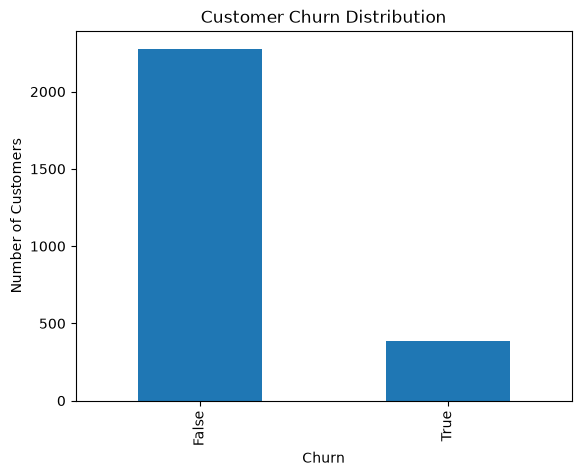

In [8]:
import matplotlib.pyplot as plt
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [9]:
pd.crosstab(df["International plan"], df["Churn"])

Churn,False,True
International plan,,
No,2126,270
Yes,152,118


In [10]:
pd.crosstab(
    df["International plan"],
    df["Churn"],
    normalize="index"
) * 100

Churn,False,True
International plan,,
No,88.731219,11.268781
Yes,56.296296,43.703704


In [11]:
pd.crosstab(
    df["Customer service calls"],
    df["Churn"],
    normalize="index"
) * 100

Churn,False,True
Customer service calls,,
0,85.765766,14.234234
1,89.523810,10.476190
2,89.802632,10.197368
3,89.367816,10.632184
4,51.879699,48.120301
5,40.816327,59.183673
6,41.176471,58.823529
7,37.500000,62.500000
8,0.000000,100.000000


In [12]:
pd.crosstab(
    df["Voice mail plan"],
    df["Churn"],
    normalize="index"
) * 100

Churn,False,True
Voice mail plan,,
No,83.290222,16.709778
Yes,91.132333,8.867667


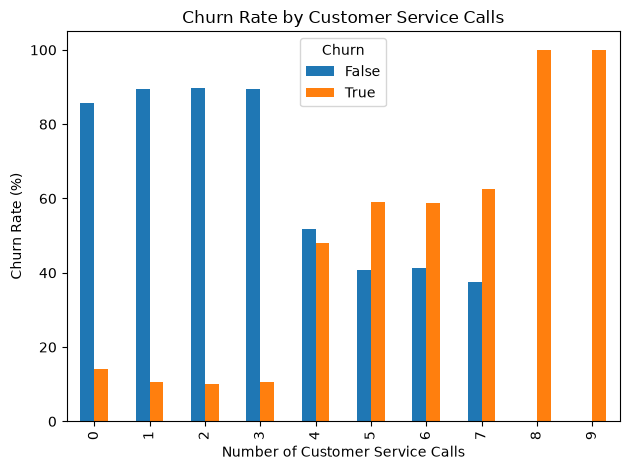

In [13]:
service_churn = pd.crosstab(
    df["Customer service calls"],
    df["Churn"],
    normalize="index"
) * 100

service_churn.plot(kind="bar")

plt.title("Churn Rate by Customer Service Calls")
plt.xlabel("Number of Customer Service Calls")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [14]:
df.groupby("Churn")["Total day minutes"].mean()

Churn
False    175.104346
True     205.181186
Name: Total day minutes, dtype: float64

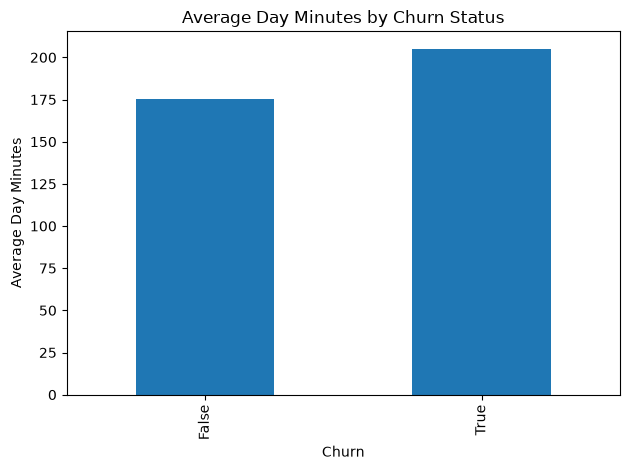

In [15]:
day_minutes = df.groupby("Churn")["Total day minutes"].mean()

day_minutes.plot(kind="bar")

plt.title("Average Day Minutes by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Day Minutes")

plt.tight_layout()
plt.show()

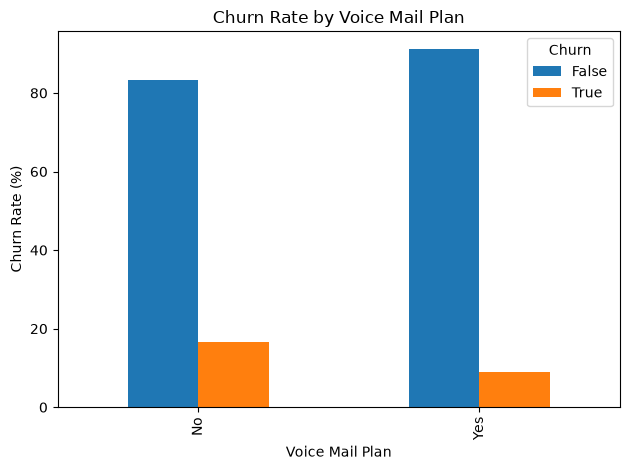

In [16]:
voicemail_churn = pd.crosstab(
    df["Voice mail plan"],
    df["Churn"],
    normalize="index"
) * 100

voicemail_churn.plot(kind="bar")

plt.title("Churn Rate by Voice Mail Plan")
plt.xlabel("Voice Mail Plan")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [19]:
charge_churn = df.groupby("Churn")["Total day charge"].mean()

charge_churn

Churn
False    29.768266
True     34.881340
Name: Total day charge, dtype: float64

In [20]:
pd.crosstab(df["Area code"], df["Churn"])

Churn,False,True
Area code,,
408,575,94
415,1123,195
510,580,99


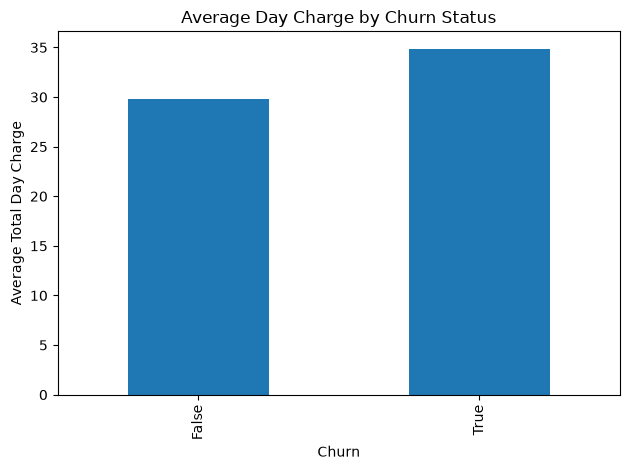

In [21]:
charge_churn = df.groupby("Churn")["Total day charge"].mean()

charge_churn.plot(kind="bar")

plt.title("Average Day Charge by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Total Day Charge")

plt.tight_layout()
plt.show()

In [22]:
# Summary of key churn-related factors

print("Churn Distribution:")
print(df["Churn"].value_counts(normalize=True) * 100)

print("\nInternational Plan vs Churn:")
print(pd.crosstab(df["International plan"], df["Churn"], normalize="index") * 100)

print("\nCustomer Service Calls vs Churn:")
print(pd.crosstab(df["Customer service calls"], df["Churn"], normalize="index") * 100)

print("\nVoice Mail Plan vs Churn:")
print(pd.crosstab(df["Voice mail plan"], df["Churn"], normalize="index") * 100)

print("\nAverage Day Minutes:")
print(df.groupby("Churn")["Total day minutes"].mean())

print("\nAverage Day Charge:")
print(df.groupby("Churn")["Total day charge"].mean())

Churn Distribution:
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64

International Plan vs Churn:
Churn                   False      True 
International plan                      
No                  88.731219  11.268781
Yes                 56.296296  43.703704

Customer Service Calls vs Churn:
Churn                       False       True 
Customer service calls                       
0                       85.765766   14.234234
1                       89.523810   10.476190
2                       89.802632   10.197368
3                       89.367816   10.632184
4                       51.879699   48.120301
5                       40.816327   59.183673
6                       41.176471   58.823529
7                       37.500000   62.500000
8                        0.000000  100.000000
9                        0.000000  100.000000

Voice Mail Plan vs Churn:
Churn                False      True 
Voice mail plan                      
No               83.

# KEY INSIGHTS

- The overall customer churn rate is approximately 14.55%.

- Customers with an International Plan have a much higher churn rate (43.70%) compared with customers without an International Plan (11.27%).

- Customer churn increases as the number of Customer Service Calls increases. Customers with 4 or more service calls show noticeably higher churn rates.

- Customers with 8 or 9 customer service calls show a 100% churn rate in this dataset, although these groups may contain fewer customers.

- Churned customers have a higher average Total Day Charge (34.88) compared with non-churned customers (29.77).

- The analysis shows that International Plan usage, frequent customer service calls, and higher day charges are associated with customer churn.

## Conclusion

The analysis shows that customer churn is influenced by several factors. Customers with an International Plan have a higher churn rate than customers without one. Frequent Customer Service Calls are also associated with higher churn. Churned customers also have a higher average Total Day Charge than non-churned customers. These findings highlight important areas that can be considered when working on customer retention.

## Recommendations

- Monitor customers who use the International Plan, as this group shows a higher churn rate.
- Provide better support and follow-up for customers who make frequent Customer Service Calls.
- Investigate the reasons for higher charges among customers who churn.
- Use customer churn patterns to identify customers who may need additional support or retention efforts.